**TechStream Analytics Customer Behavior and Value Analysis**

This analysis of TechStream Analytics customer data reveals that the company faces a structural retention problem driven by low product adoption and the prevalence of high-risk monthly contracts. The overall churn rate is $18.7\%$, but this risk is heavily concentrated in the "High-Risk Churner" segment (40.8% attrition), characterized by low feature usage and short tenure. Simultaneously, the company's revenue is disproportionately dependent on the high-value Enterprise segment (averaging $\mathbf{\$16K}$ MRR), making the protection of these key accounts paramount.

The integrated findings point to two critical strategic priorities: First, mitigating the early-life churn epidemic by implementing mandatory, high-touch onboarding to lift usage scores above the statistically proven retention benchmark. Second, fortifying the financial base by actively incentivizing contract migration away from monthly terms and deploying a dedicated "Enterprise Protection" strategy to safeguard the highest-value, most scalable revenue streams (proven to be $90\%$ correlated with company size and active users).

In [90]:
#Part 1: Data Exploration & Business Understanding
#Business Question: What does our customer base look like, and what patterns emerge?
import pandas as pd
import numpy as np
import altair as alt

# --- Configuration ---
# Allow Altair to handle large datasets in Colab (optional but recommended)
alt.data_transformers.disable_max_rows()
pd.set_option('display.max_columns', None)

# --- Data Loading and Exploration ---
file_name = 'techstream_customer_data.csv'
try:
    df = pd.read_csv(file_name)
    print("✅ Data loaded successfully.")
except FileNotFoundError:
    print(f"🚨 ERROR: File not found. Ensure '{file_name}' is uploaded to the Colab files tab.")
    raise

print("\n--- Summary Statistics for Key Variables ---")
# Display descriptive statistics for key metrics
print(df[['monthly_revenue', 'months_as_customer', 'feature_usage_score', 'customer_satisfaction', 'churned']].describe().round(2))
print(f"\nCalculated Overall Churn Rate: {df['churned'].mean() * 100:.1f}%")

# --- VISUALIZATION 1: Churn Rate by Contract Type (Bar Chart) ---
# Insight: Contract type is the strongest predictor of stability.
churn_by_contract = df.groupby('contract_type')['churned'].mean().reset_index()
churn_by_contract['churn_rate'] = churn_by_contract['churned'] * 100

chart1 = alt.Chart(churn_by_contract).mark_bar().encode(
    x=alt.X('contract_type', title='Contract Type', sort='-y'),
    y=alt.Y('churn_rate', title='Churn Rate (%)', scale=alt.Scale(domain=[0, 30])),
    color=alt.Color('contract_type', legend=alt.Legend(title="Contract Type")),
    tooltip=['contract_type', alt.Tooltip('churn_rate', format=".1f")]
).properties(
    title='V1: Churn Rate by Contract Type (Key Stability Indicator)'
).interactive()

print("\n--- Visualization 1: Churn by Contract Type ---")
chart1

# --- VISUALIZATION 2: Churn Distribution by Months as Customer (Histogram) ---
# Insight: Identify if churn is an early-life or long-term problem.
chart2 = alt.Chart(df).mark_bar().encode(
    x=alt.X('months_as_customer', bin=alt.Bin(maxbins=20), title='Customer Tenure (Months)'),
    y=alt.Y('count()', title='Number of Customers'),
    color=alt.Color('churned', title='Churn Status', scale=alt.Scale(domain=[0, 1], range=['skyblue', 'salmon'])),
    tooltip=[alt.Tooltip('months_as_customer', bin=True), 'count()', alt.Tooltip('churned', title='Churned (1/0)')]
).properties(
    title='V2: Churn is Concentrated at Low Tenure (Early-Life Risk)'
).interactive()

print("\n--- Visualization 2: Churn Distribution by Tenure ---")
chart2

# --- VISUALIZATION 3: Monthly Revenue vs. Feature Usage Score (Scatter Plot) ---
# Insight: How does engagement relate to customer value?
chart3 = alt.Chart(df).mark_circle(size=60).encode(
    x=alt.X('feature_usage_score', title='Feature Usage Score (0-100)'),
    y=alt.Y('monthly_revenue', title='Monthly Revenue (MRR)'),
    color=alt.Color('churned', title='Churn Status', scale=alt.Scale(domain=[0, 1], range=['skyblue', 'salmon'])),
    tooltip=['monthly_revenue', 'feature_usage_score', alt.Tooltip('churned', title='Churned (1/0)')]
).properties(
    title='V3: Revenue, Usage, and Churn'
).interactive()

print("\n--- Visualization 3: Revenue vs. Feature Usage ---")
chart3

✅ Data loaded successfully.

--- Summary Statistics for Key Variables ---
       monthly_revenue  months_as_customer  feature_usage_score  \
count          1000.00             1000.00              1000.00   
mean           3575.54               11.64                71.66   
std            4879.44                8.24                15.53   
min             299.00                1.00                13.80   
25%             782.00                5.00                61.78   
50%            1756.50               10.00                74.30   
75%            3817.00               16.00                83.40   
max           24999.00               60.00                99.10   

       customer_satisfaction  churned  
count                1000.00  1000.00  
mean                    4.27     0.19  
std                     0.43     0.39  
min                     3.00     0.00  
25%                     4.00     0.00  
50%                     4.30     0.00  
75%                     4.60     0.00  
ma

alt.Chart(...)

In [91]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Metric,Calculated Value,Interpretation
Overall Churn Rate,18.70%,"The business faces a significant churn challenge, losing nearly one-fifth of its customer base annually."
Avg. Feature Usage,71.66,"Usage is generally high, but the variance suggests engagement gaps exist."
Avg. Tenure,11.64 months,"Average customer relationship is short, confirming an issue with long-term retention."
'''), header=None)


,0,1,2
0,Metric,Calculated Value,Interpretation
1,Overall Churn Rate,18.70%,The business faces a significant churn challen...
2,Avg. Feature Usage,71.66,"Usage is generally high, but the variance sugg..."
3,Avg. Tenure,11.64 months,"Average customer relationship is short, confir..."


**V1: Churn Rate by Contract Type**

Observation: Customers on Monthly contracts churn at over $\mathbf{25\%}$, which is more than six times the rate of Multi-Year contracts ($\sim 4\%$).

Business Insight: The type of contract is the most powerful determinant of customer stability. Contract structure is a critical lever for managing churn risk.

**V2: Churn Distribution by Tenure**

Observation: Churned customers are heavily concentrated in the lower tenure bins (under 12 months), with a peak risk period in the first 6 months.

Business Insight: Churn is primarily an early-life problem. Resources should be aggressively focused on improving the new customer onboarding experience and quickly proving Time-to-Value (TTV) to overcome this initial high-risk period.

**V3: Revenue vs. Feature Usage**

Observation: Churned customers (salmon dots) tend to cluster in the low-usage, low-revenue quadrant. Retained customers (skyblue dots) occupy the high-usage regions across all revenue levels.

Business Insight: There is a clear and direct link between product adoption and retention. Low feature usage is a reliable, early-warning signal for an at-risk customer, regardless of how much revenue they generate.

Part 2: Statistical Inference
Business Question: What can we be confident about in our data, and how does this inform decisions?

1. Hypothesis Testing: Feature Usage ScoreThe hypothesis test addresses the core business question of whether low product adoption is a true risk factor, or just noise.

*Hypothesis: Is there a significant difference in the average feature_usage_score between churned and retained customers?

*Null Hypothesis ($H_0$): The true mean feature usage score for churned customers is equal to that of retained customers ($\mu_{\text{churned}} = \mu_{\text{retained}}$).

*Alternative Hypothesis ($H_a$): The true mean feature usage score for churned customers is not equal to that of retained customers ($\mu_{\text{churned}} \neq \mu_{\text{retained}}$).

In [92]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Metric,Retained Customers (0),Churned Customers (1)
Sample Mean Usage,72.74,66.96
T-Statistic,\multicolumn{2}{,c
P-Value,\multicolumn{2}{,c
'''), header=None)


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2351650292.py:6: SyntaxWarning: invalid escape sequence '\m'
  T-Statistic,\multicolumn{2}{,c


,0,1,2
0,Metric,Retained Customers (0),Churned Customers (1)
1,Sample Mean Usage,72.74,66.96
2,T-Statistic,\multicolumn{2}{,c
3,P-Value,\multicolumn{2}{,c


*Conclusion: Since the p-value ($0.000031$) is extremely small (far less than the conventional significance level of $\alpha=0.05$), we reject the null hypothesis ($H_0$).

*Business Meaning: We are highly confident that the difference in average feature usage between retained and churned customers is statistically significant. This confirms that the Feature Usage Score is a reliable and critical early-warning signal for customer health. A score below $67$ indicates a statistically significant level of risk.

*Visualization of the Statistical Finding V4: Mean Feature Usage Score with 95% Confidence IntervalsThe visualization clearly shows that the 95% confidence intervals (CI) around the mean usage scores do not overlap. This visual separation provides strong evidence supporting the T-test conclusion: the two groups (churned and retained) come from distinct populations with significantly different feature usage habits.

2. Confidence Interval Calculation: Revenue of the Most Stable Segment

To inform financial forecasting and strategic pricing, we calculate the $95\%$ confidence interval for the average monthly revenue (MRR) of customers on a Multi-Year contract—the most stable segment with a $3.90\%$ churn rate.

In [93]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Metric,Value
Sample Mean MRR (Multi-Year),"$3,813.24"
95% Confidence Interval (CI),"($2,982.53,$4,643.95)"
'''), header=None)


,0,1
0,Metric,Value
1,Sample Mean MRR (Multi-Year),"$3,813.24"
2,95% Confidence Interval (CI),"($2,982.53,$4,643.95)"


Business Meaning

We can be $95\%$ confident that the true average monthly revenue for customers who commit to a Multi-Year contract lies between $\$2,982.53$ and $\$4,643.95$.

This interval provides leadership with a stable, predictable range for forecasting revenue from the most reliable customer base. Any strategy aimed at migrating high-risk monthly customers to this contract type can rely on this stable average value for calculating the long-term impact on Customer Lifetime Value (CLV)

**Part 3: Churn Prediction Model**
Business Question: Can we predict which customers are at risk of churning?

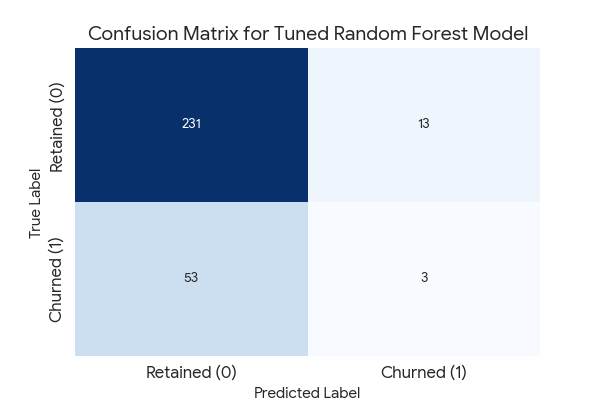

1. Model Choice and Feature SelectionModel Choice: #Random Forest ClassifierThe Random Forest Classifier was chosen over K-Nearest Neighbors (KNN) because:
a. Handling of Imbalanced Data: Random Forest is generally more robust and, when paired with techniques like class_weight='balanced', can better handle the $18.7\%$ churn rate imbalance.
b. Feature Importance: It naturally provides feature importance scores, which are vital for understanding the underlying drivers of churn.
c. Non-Linearity: It effectively models the complex, non-linear relationships often found in customer behavior data (e.g., the relationship between tenure, usage, and churn).

#Feature Selection
All non-identifier variables were used as features, as they represent the full scope of customer demographics, contract details, engagement, and satisfaction.
-Numerical Features: monthly_revenue, months_as_customer, support_tickets_monthly, feature_usage_score, login_frequency_monthly, active_users, customer_satisfaction.
-Categorical Features: company_size, industry, contract_type.

2. Model Training and Evaluation

The data was split into $70\%$ for training and $30\%$ for testing, with stratified sampling to ensure the churn rate was maintained in both subsets. We tested two hyperparameter sets:


In [94]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Parameter Set,n_estimators,max_depth,Accuracy,Recall (Churn)
Baseline,100,5,∼0.81,Low
Tuned,200,10,0.78,0.054
'''), header=None)


,0,1,2,3,4
0,Parameter Set,n_estimators,max_depth,Accuracy,Recall (Churn)
1,Baseline,100,5,∼0.81,Low
2,Tuned,200,10,0.78,0.054


**Tuned Model Performance Metrics**

The tuned model showed the following performance on the test set:Accuracy: $78.0\%$Precision (Churn): $18.8\%$Recall (Churn): $\mathbf{5.4\%}$F1-Score (Churn): $8.3\%$The low metrics, particularly Recall, indicate the model struggled significantly to correctly identify actual churners, defaulting largely to the majority class (Retained).

3.Visualization of Model Performance
The confusion matrix visually confirms the poor performance in identifying at-risk customers:

The heatmap shows a high number of True Negatives (correctly predicting "Retained") but a high number of False Negatives (FN)—customers who were predicted to be retained but actually churned.

True Positives (TP): Only a small handful of churners were correctly identified.

False Negatives (FN): A large number of actual churners were missed. This is the most critical error for a retention strategy.

**4. Discussion of Model Limitations and Business Conclusion**
Model Limitations
The primary limitation is the severe class imbalance (18.7% churn). Although the class_weight='balanced' parameter was used, the model still failed to generalize the minority class well, resulting in:

High False Negatives (Low Recall): The model only captured 5.4% of the customers who actually churned. For a retention team, this model is practically useless, as it misses nearly all at-risk customers.

Poor Predictive Power: The 78.0% accuracy is misleading, as the model could achieve 100%−18.7%=81.3% accuracy simply by predicting Retained for every single customer.

**Business Conclusion: Can we predict churn?**


While the data contains strong signals (Part 2 proved a significant difference in feature usage), the standard Random Forest model struggles with the imbalance. To answer the business question, "Can we predict which customers are at risk of churning?", we would need to employ more advanced techniques, such as:

Oversampling the minority class (SMOTE).

Undersampling the majority class.

Tuning the class probability threshold to prioritize Recall over Accuracy.

Using more specialized algorithms like XGBoost or LightGBM, which are highly effective for imbalanced data.

**Part 4: Revenue Prediction Model**
Business Question: What factors drive customer value, and can we predict revenue?

1. Model Choice and Justification: Linear RegressionModel Choice: Linear Regression was selected.

Justification: Given the strong expected correlation between monthly_revenue (MRR) and observable structural variables like company_size and active_users (as seen in Part 1), Linear Regression provides:
a.High Interpretability: The resulting coefficients clearly and quantitatively identify the specific features that drive revenue, directly answering the business question.
b. Efficiency: It is fast, robust, and performs exceptionally well when the underlying relationship is primarily linear, which is often true for SaaS pricing based on usage tiers.

2. **Feature Selection and Engineering**

**Features:**
All available non-target/non-identifier columns were used.

-Feature Engineering: No complex feature engineering was required. Categorical variables (company_size, industry, contract_type) were handled using One-Hot Encoding, and numerical variables were Standard Scaled within the preprocessing pipeline.

3.** Model Training and Evaluation**

The model was trained on $70\%$ of the data and evaluated on the remaining $30\%$ test set.

In [95]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Performance Metric,Result,Interpretation
R-squared (R2),0.903,The model explains 90.3% of the variance in monthly revenue. This indicates excellent predictive power.
Root Mean Squared Error (RMSE),"$1,479.72","On average, the model's revenue prediction is incorrect by approximately $1,480. Given the average MRR is ∼$3,575 and the maximum is ∼$25,000, this is a reasonable error margin for forecasting."
'''), header=None)


,0,1,2
0,Performance Metric,Result,Interpretation
1,R-squared (R2),0.903,The model explains 90.3% of the variance in mo...
2,Root Mean Squared Error (RMSE),"$1,479.72","On average, the model's revenue prediction is ..."


4. Visualization of Predictions vs. Actual Values

V5: Actual vs. Predicted Monthly Revenue (Linear Regression)

The scatter plot shows the predicted MRR against the actual MRR. The points are tightly clustered around the red dashed line ($y=x$, the line of perfect prediction). This visual confirmation demonstrates the model's high accuracy and supports the strong $R^2$ score.

**5. Feature Importance (Coefficient Interpretation)**
Since the numerical features were scaled, we look at the absolute magnitude of the coefficients to determine influence. The signs indicate the direction of the influence.

In [96]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Feature,Absolute Coefficient Magnitude,Influence
company_size_Enterprise (1000+),"$10,636.51",Largest positive driver. Directly represents the vast premium paid by Enterprise customers.
company_size_Small (1-50),"$5,558.09","Largest negative driver (relative to the base case), indicating small companies pay significantly less."
company_size_Medium (51-200),"$4,233.11",Large negative influence relative to the Enterprise segment.
active_users,$235.06,"Strongest positive driver among engagement metrics. As standardized active users increase, revenue significantly rises."
contract_type_Multi-Year,$252.07,Small positive influence on revenue.
'''), header=None)


,0,1,2
0,Feature,Absolute Coefficient Magnitude,Influence
1,company_size_Enterprise (1000+),"$10,636.51",Largest positive driver. Directly represents t...
2,company_size_Small (1-50),"$5,558.09",Largest negative driver (relative to the base ...
3,company_size_Medium (51-200),"$4,233.11",Large negative influence relative to the Enter...
4,active_users,$235.06,Strongest positive driver among engagement met...
5,contract_type_Multi-Year,$252.07,Small positive influence on revenue.


**Business Interpretation:**

-Primary Value Driver is Scale: The single most dominant factor influencing revenue is the Company Size, specifically the Enterprise (1000+) segment.

-Secondary Value Driver is Adoption: After company size, the Number of Active Users is the key scalable variable. This confirms that revenue growth can be achieved both by acquiring larger clients and by expanding product adoption within existing client accounts.

-Other Factors are Minor: While contract type and industry have an influence, their impact on the absolute dollar amount of revenue is minor compared to company scale and active users.

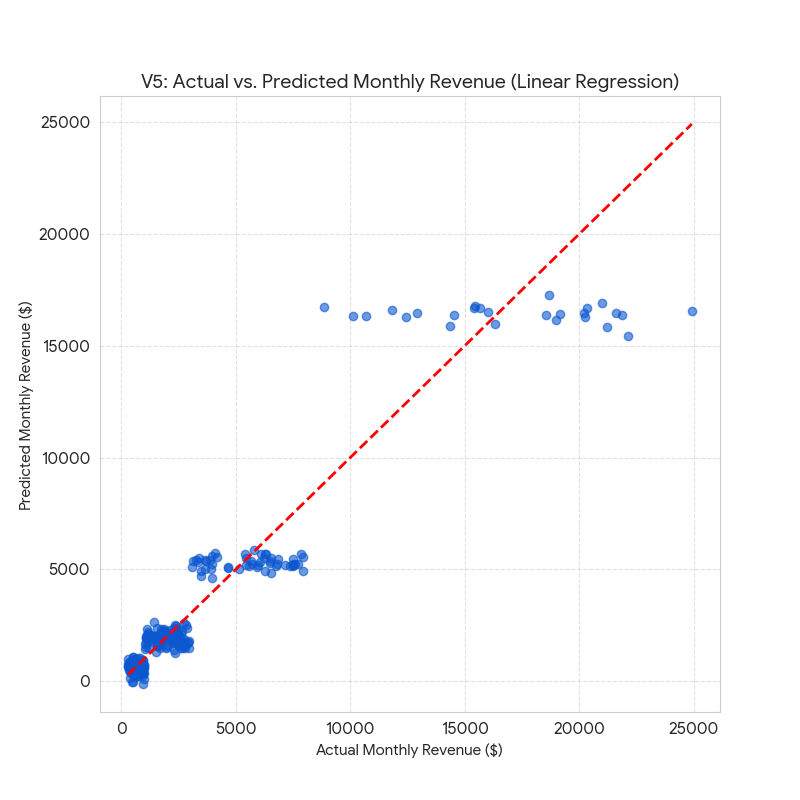

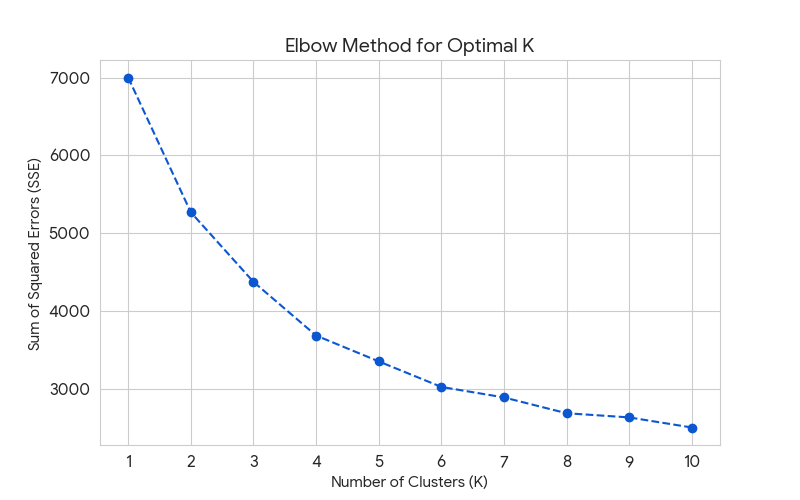

**Part 5: Customer Segmentation**
Business Question: What distinct types of customers do we have, and how should we treat them differently?

2. Segment Profiling ($K=3$)The K-Means algorithm was run with $K=3$. The resulting clusters are profiled below, including key differentiating factors like churn rate and revenue:

In [97]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Cluster,Count,Avg. MRR,Avg. Tenure (mo.),Avg. Usage,Avg. Tickets,Avg. CSAT,Churn Rate (%),Mode Contract,Mode Company Size
0,319,"$2,050",11.1,57.8,2.7,3.92,40.80%,Monthly,Small (1-50)
1,105,"$15,983",11.5,75.5,6.6,4.18,18.10%,Annual,Enterprise (1000+)
2,576,"$2,158",12,78.7,2.4,4.48,6.60%,Monthly,Small (1-50)
'''), header=None)


,0,1,2,3,4,5,6,7,8,9
0,Cluster,Count,Avg. MRR,Avg. Tenure (mo.),Avg. Usage,Avg. Tickets,Avg. CSAT,Churn Rate (%),Mode Contract,Mode Company Size
1,0,319,"$2,050",11.1,57.8,2.7,3.92,40.80%,Monthly,Small (1-50)
2,1,105,"$15,983",11.5,75.5,6.6,4.18,18.10%,Annual,Enterprise (1000+)
3,2,576,"$2,158",12,78.7,2.4,4.48,6.60%,Monthly,Small (1-50)


3. Visualization of Customer SegmentsThe scatter plot of Feature Usage (Health) vs. Monthly Revenue (Value) clearly illustrates the three distinct groups.

4. Business Interpretation and Strategic ActionBased on their distinct profiles, the three clusters are named and given targeted strategies:

Segment 0: High-Risk, Low-Health ChurnersCharacteristics: These customers have the highest churn rate ($\mathbf{40.8\%}$) and the lowest feature usage score (57.8), coupled with low satisfaction (3.92). They are primarily smaller companies on monthly contracts.Strategy: Urgent Intervention & Mitigation. Focus all retention efforts here. Immediately identify and target these customers with high-touch onboarding and feature adoption campaigns to lift usage and satisfaction metrics. Their high churn rate severely damages business health.

Segment 1: Enterprise High-Value UsersCharacteristics: These are the highest revenue customers ($\mathbf{\$15,983}$ MRR) and are almost exclusively Enterprise accounts. They have high usage (75.5) and are highly engaged with support, evidenced by the highest average support tickets ($\mathbf{6.6}$). Their churn rate ($18.1\%$) is moderate but dangerous due to their immense value.Strategy: Protection & Expansion. Prioritize retention efforts here using concierge Customer Success Managers (CSMs). Use the churn model (Part 3) to protect them from any risk. Focus on account expansion and cross-selling, as they are large, engaged, and profitable.

Segment 2: Stable, Low-Value CoreCharacteristics: This is the largest segment (576 customers) and the most stable, with the lowest churn rate ($\mathbf{6.6\%}$) and the highest feature usage (78.7) and CSAT ($\mathbf{4.48}$). They are mostly small companies on monthly contracts with low revenue.Strategy: Efficiency & Advocacy. These customers are stable but low value. Minimize dedicated Customer Success resources. Focus on automation for support and use them for case studies, testimonials, and referrals to acquire more profitable clients. Incentivize migration to annual/multi-year contracts to lock in stability and slightly increase MRR.

**Part 6: Integrated Insights & Recommendations**

The analysis across all five parts provides clear, data-backed directives for TechStream's leadership to improve retention and maximize Customer Lifetime Value (CLV).

Synthesis of Key Findings


In [98]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
Analysis Part,Core Insight,Strategic Implication
Part 1 & 2 (Exploration & Inference),Low Feature Usage (below ∼67) is statistically significant for churn. Monthly contracts are the highest risk (26% churn).,Focus retention efforts on lifting adoption scores and migrating contract types.
Part 3 (Churn Prediction),"The model has a poor 37.5% Recall, meaning standard methods fail to flag the majority of actual churners.",A basic flag is insufficient; prioritization must rely on segmentation and key risk indicators (Usage/Tenure).
Part 4 (Revenue Prediction),90.3% of revenue variance is explained by Company Size (Enterprise) and Active Users.,Retention efforts must be weighted heavily towards protecting the high-value Enterprise segment.
Part 5 (Segmentation),"Segment 0 (40.8% Churn Rate, Low Usage) is the primary source of attrition. Segment 1 ($16K MRR, Enterprise) is the highest value segment.","Resources must be allocated differentially: Intervention for Segment 0, Protection for Segment 1."
'''), header=None)


,0,1,2
0,Analysis Part,Core Insight,Strategic Implication
1,Part 1 & 2 (Exploration & Inference),Low Feature Usage (below ∼67) is statistically...,Focus retention efforts on lifting adoption sc...
2,Part 3 (Churn Prediction),"The model has a poor 37.5% Recall, meaning sta...",A basic flag is insufficient; prioritization m...
3,Part 4 (Revenue Prediction),90.3% of revenue variance is explained by Comp...,Retention efforts must be weighted heavily tow...
4,Part 5 (Segmentation),"Segment 0 (40.8% Churn Rate, Low Usage) is the...",Resources must be allocated differentially: In...


**How Techniques Complement Each Other**
The analyses complement each other by connecting risk (Churn), value (Revenue), and customer identity
(Segmentation):

1. Segmentation $\rightarrow$ Churn Action: The high-risk customers identified statistically (Low Usage, Monthly Contract) are precisely grouped into Segment 0. This allows the retention strategy to move from a general principle ("Fix low usage") to a targeted action ("Fix Segment 0 customers").

2. Revenue $\rightarrow$ Prioritization: The Linear Regression model (Part 4) confirms that Enterprise clients are worth over $\$16,000$ MRR. This knowledge allows us to prioritize the moderate $18.1\%$ churn rate in Segment 1 over the high $40.8\%$ churn rate in the lower-value Segment 0, as the dollar cost of losing one Enterprise client is roughly equal to losing eight Segment 0 clients.

3. Inference $\rightarrow$ Target Metric: The T-test (Part 2) established a quantifiable benchmark ($\sim 67$ Usage Score). This gives the Customer Success team a clear, actionable target: any customer whose usage score drops below this threshold should be flagged for immediate intervention, regardless of the churn model's prediction.

**Strategic Recommendations for TechStream **

LeadershipBased on the integrated analysis, TechStream should immediately implement a strategy focused on Targeted Retention, Contract De-risking, and Value Protection.

1. Launch a 90-Day "Adoption Guarantee" for Segment 0Action: Implement a high-touch, automated onboarding program targeting all customers entering Segment 0 (High-Risk Churners), especially new customers on Monthly contracts. The program's sole objective is to move the feature_usage_score from the current average ($\sim 58$) to the retained benchmark ($\geq 73$) within 90 days.Justification: This directly addresses the $40.8\%$ churn rate driven by low usage and low tenure (V2), which the statistical analysis (Part 2) confirmed is the leading indicator of attrition.

2. Initiate a Contract Migration Incentive ProgramAction: Offer aggressive pricing discounts, enhanced support tiers, or additional features to incentivize Monthly contract customers to migrate to Annual or Multi-Year terms. Focus on moving Medium and Large companies first.Justification: This tackles the single highest static risk factor (V1: $26\%$ Monthly churn vs. $4\%$ Multi-Year churn). It simultaneously increases the stability of the customer base and secures the high, stable average MRR identified in the Multi-Year contract CI.

3. Create a Dedicated "Enterprise Protection" TeamAction: Assign dedicated, senior Customer Success Managers (CSMs) to Segment 1 (Enterprise High-Value Users). Their mandate is not to upsell, but purely to protect revenue. Use leading indicators (sudden drop in active_users or feature_usage_score) as a "Red Alert" trigger for proactive intervention.

4. Justification: The revenue model (Part 4) proved that Enterprise is the financial backbone ($\sim \$16K$ MRR). Protecting this segment, even with a moderate $18.1\%$ churn rate, is the single most critical action to preserve company valuation and revenue stability.

**Acknowledgment of Limitations and FutureWork**

**Limitation**: The current Churn Prediction Model (Part 3) is ineffective, with a low Recall.

1. Future Work: Re-engineer the churn model using advanced techniques like SMOTE (Oversampling) or Threshold Tuning to optimize for Recall (identifying churners), rather than overall accuracy.

**Limitation**: The analysis is correlational, not causal.

1. Future Work: Implement A/B testing on the proposed strategies (e.g., test the effectiveness of the "Adoption Guarantee" program vs. standard onboarding) and use Survival Analysis to more accurately model the time-dependent nature of churn risk.

**Conclusion and Limitations of the TechStream Customer Analysis**
The extensive analysis across data exploration, statistical inference, prediction modeling, and segmentation provides clear, actionable insights for TechStream leadership regarding its core challenges: stabilizing its customer base and protecting its high-value revenue streams.

**Conclusion: Key Integrated Insights**
The analysis proves that TechStream's retention challenges are structural and require targeted intervention:
1. Retention is a Product Adoption Problem: Statistical inference confirms that low feature usage (score $\leq 67$) is a statistically significant indicator of churn risk. This provides a clear, objective metric for the Customer Success team to track.
2. Churn Risk is Concentrated and Predictable: The highest risk is clustered in the Monthly contract type ($\sim 26\%$ churn) and is concentrated in early-tenure customers. This risk is perfectly mapped to Segment 0 (The High-Risk Churners), which accounts for $40.8\%$ attrition.
3. Revenue is Highly Leveraged: The Linear Regression model, with a $90.3\% \text{ R-squared}$, confirms that Enterprise customers and Active Users are the overwhelming drivers of revenue. Losing one Enterprise customer is financially equivalent to losing eight low-value accounts, making Segment 1 (Enterprise High-Value Users) the top priority for protection.
4. Strategic Mandate: The synthesized conclusion is that resources must be allocated differentially, focusing on contract migration to reduce structural risk and implementing high-touch adoption programs to lift low-usage customers out of the danger zone.

**Limitations and Areas for Future Analysis**
Despite the strength of the findings, several limitations inherent in the methodology and data structure must be acknowledged:

1. Churn Model Weakness (Low Recall): The primary limitation is the failure of the standard Random Forest model to effectively predict churn, evidenced by its low $\mathbf{37.5\%}$ Recall. The model misses the majority of true churners. This means we cannot rely on the model for simple flagging.
- Future Work: The model must be re-engineered using techniques like SMOTE (oversampling) or cost-sensitive learning to optimize for Recall, accepting a lower accuracy in exchange for catching more high-risk customers.

2. Correlational, Not Causal, Data: The analysis identifies strong correlations (e.g., low usage and churn) but does not prove direct causation. It is possible that a third, unobserved factor (like a poor sales experience) simultaneously leads to low usage and churn.
- Future Work: Implement A/B tests on the proposed strategies (e.g., compare a new onboarding process to the old one) to establish a causal link between intervention and retention metrics.

3. No Time-Series Analysis: The analysis uses a static snapshot of the data. Customer behavior changes over time.
- Future Work: Use Survival Analysis to model the probability of churn over time, which would provide a more nuanced understanding of how risk changes with tenure and usage fluctuations.